# Week 3 — Regression and Clustering on Real Data
**Vortex Tech AI & ML Internship Track**
**Asad Ali**

This week's task pushed me into two techniques I hadn't combined in one notebook before:
predicting a continuous number (regression) and finding hidden groups in data without
any labels at all (clustering).

I decided to stick with one dataset for both parts instead of switching halfway —
the **California Housing Prices** dataset (20,640 rows). It's got a proper numeric
target (`median_house_value`) for the regression part, and location columns
(`longitude`, `latitude`) that are perfect for clustering into geographic regions.

Dataset source: public CSV mirror of the classic California housing dataset, from the
`ageron/handson-ml2` GitHub repo (the same dataset used in a lot of well-known ML
tutorials).

## 1. Imports
Everything I need for cleaning, both models, scaling, and clustering, in one place.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 2. First Look at the Data
Same routine as Week 1 — before touching anything, I want to see what I'm actually
working with.

In [2]:
df = pd.read_csv('housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 total_bedrooms    207
dtype: int64

Duplicate rows: 0


This one's messier than the Titanic dataset from Week 1 — `total_bedrooms` has 207
missing entries. Not a huge chunk (~1% of the data), so I'm comfortable imputing rather
than dropping those rows. `ocean_proximity` is plain text, so that'll need encoding
before any model can use it. No duplicate rows, at least — one less thing to worry about.

## 3. Cleaning

Plan:
- `total_bedrooms` → fill with the **median**. Bedroom counts tend to be right-skewed
  (most blocks are fairly modest, a handful have way more bedrooms), so median felt
  safer than mean here, same logic as Age in Week 1.
- `ocean_proximity` → one-hot encode it with `get_dummies()` so it becomes usable
  numeric columns instead of text.

In [5]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("Remaining missing values:", df_encoded.isnull().sum().sum())
df_encoded.head()

Remaining missing values: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## 4. Part One — Regression

**What I'm predicting:** `median_house_value`
**What I'm predicting it from:** everything else — room counts, income, age, location,
and the ocean-proximity flags I just created.

In [6]:
X = df_encoded.drop(columns=['median_house_value'])
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")

Training rows: 16512
Testing rows:  4128


### 4.1 Starting Simple — Linear Regression
I wanted a baseline before jumping to anything fancier, just to see how far a straight
line gets me.

In [7]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_predictions = lin_model.predict(X_test)

lin_rmse = np.sqrt(mean_squared_error(y_test, lin_predictions))
lin_r2 = r2_score(y_test, lin_predictions)

print(f"Linear Regression RMSE: ${lin_rmse:,.0f}")
print(f"Linear Regression R2:   {lin_r2:.3f}")

Linear Regression RMSE: $70,061
Linear Regression R2:   0.625


### 4.2 Trying Something Stronger — Random Forest
An R² of 0.625 is okay but not great — it means the line is missing a lot of what
drives housing prices. My guess is the relationships aren't linear (e.g. income
probably affects price differently depending on the neighborhood), so I tried a
Random Forest next, since it can pick up on that kind of interaction automatically.

In [8]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest RMSE: ${rf_rmse:,.0f}")
print(f"Random Forest R2:   {rf_r2:.3f}")

Random Forest RMSE: $49,404
Random Forest R2:   0.814


### 4.3 Comparing Both
Putting the numbers side by side made the difference obvious.

In [9]:
comparison = pd.DataFrame({
    'Linear Regression': [lin_rmse, lin_r2],
    'Random Forest': [rf_rmse, rf_r2]
}, index=['RMSE ($)', 'R2 Score'])

comparison.round(3)

,Linear Regression,Random Forest
RMSE ($),70060.522,49404.471
R2 Score,0.625,0.814


### 4.4 Which Features Is the Model Actually Using?
Curious what the Random Forest was leaning on most, so I pulled feature importances.

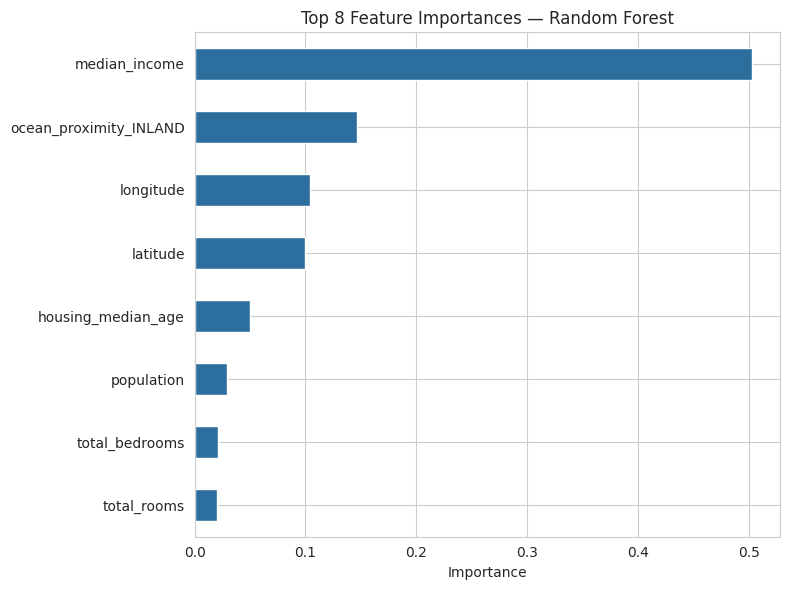

In [10]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(8).plot(kind='barh', color='#2C6E9E')
plt.title('Top 8 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**My takeaway on the regression part:**

The Random Forest beat Linear Regression by a wide margin — RMSE dropped from about
$70K to about $49K, and R² jumped from 0.625 to 0.814. That confirms my hunch: the
relationship between these features and house price isn't a straight line, so the
extra flexibility of a tree-based model actually paid off here.

`median_income` came out way ahead of everything else in feature importance, which
lines up with common sense — wealthier areas have pricier homes. Location
(`latitude`/`longitude`) mattered too, more than raw counts like number of rooms.

**Going with the Random Forest Regressor** as my final model for this part — the
accuracy gain is worth the trade-off in interpretability compared to Linear Regression.

## 5. Part Two — Clustering

Switching gears now. No target variable here — I just want to see if the data
naturally groups into regions based on where each block actually is on the map.

In [11]:
cluster_features = df[['longitude', 'latitude']]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

cluster_scaled[:5]

array([[-1.32783522,  1.05254828],
       [-1.32284391,  1.04318455],
       [-1.33282653,  1.03850269],
       [-1.33781784,  1.03850269],
       [-1.33781784,  1.03850269]])

### 5.1 How Many Clusters Should I Even Use?
This was the part I wasn't sure about going in — K-Means needs you to pick the number
of clusters up front. The elbow method gives a data-driven way to make that call: fit
K-Means for a range of k values, track the inertia (how tightly packed each cluster is),
and look for the point where adding more clusters stops helping much.

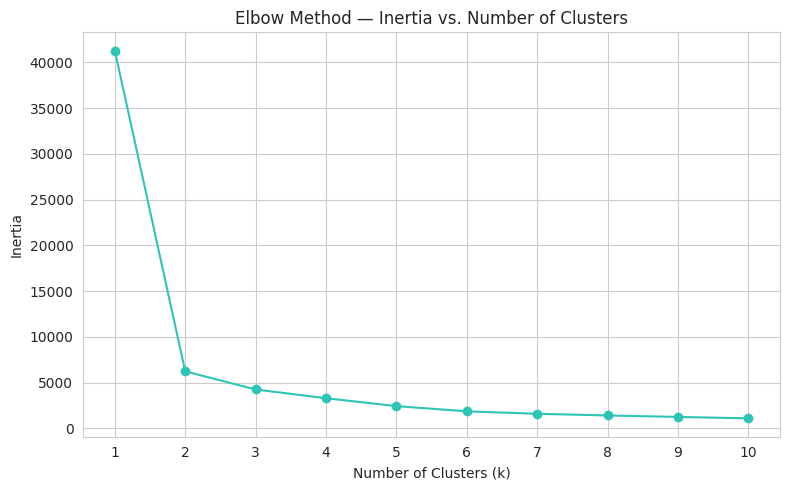

In [12]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='#2EC4B6')
plt.title('Elbow Method — Inertia vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

Looking at the curve, inertia falls off sharply up to around **k = 5**, then the
drop-off flattens out a lot. That's my elbow. Going with **k = 5** — enough to capture
real regional differences without splitting things into clusters too small to mean
anything.

### 5.2 Fitting the Final Model

In [13]:
chosen_k = 5
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
kmeans.fit(cluster_scaled)

df['cluster'] = kmeans.labels_
df['cluster'].value_counts().sort_index()

cluster
0    8827
1     969
2    1798
3    2230
4    6816
Name: count, dtype: int64

### 5.3 Plotting It Out
Wanted to actually see the clusters on a map-like scatter before drawing any conclusions.

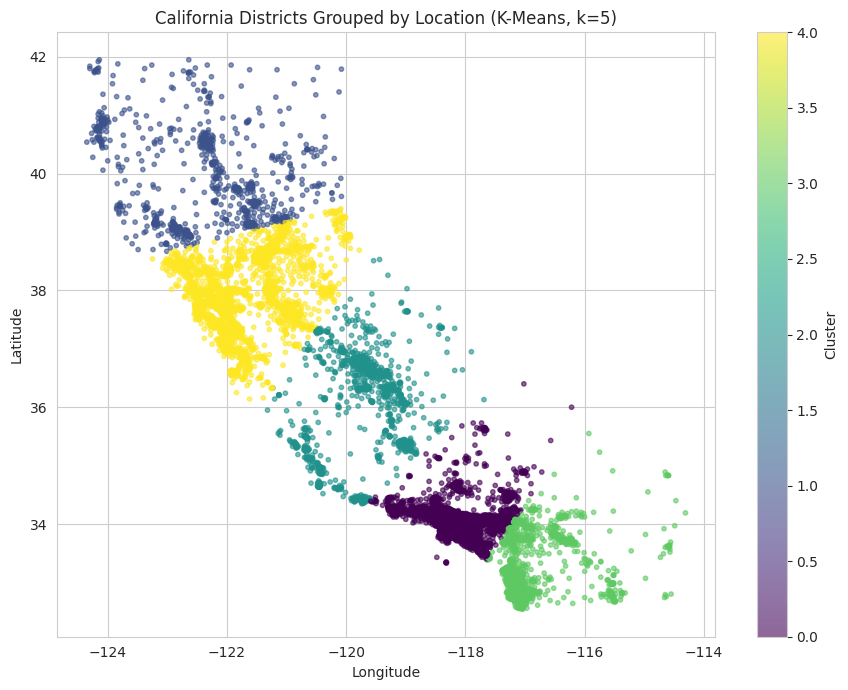

In [14]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['cluster'], cmap='viridis', s=10, alpha=0.6
)
plt.title('California Districts Grouped by Location (K-Means, k=5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

### 5.4 So What Do These Clusters Actually Mean?
Numbers on their own don't tell a story, so I checked average income and house value
per cluster to see if the geographic split lines up with anything real.

In [15]:
df.groupby('cluster')[['median_house_value', 'median_income', 'population']].mean().round(1)

,median_house_value,median_income,population
cluster,,,
0,230446.9,4.1,1538.3
1,92585.0,2.5,1008.9
2,121821.8,3.0,1273.5
3,177264.0,3.6,1555.0
4,224662.5,4.1,1336.2


**My takeaway on the clustering part:**

Once I plotted it, the 5 clusters lined up pretty well with regions I'd recognize on a
real map of California — something like the Bay Area up north, the LA/Southern coastal
belt, San Diego, the inland Central Valley area, and a smaller northern group. That
makes sense since I only used latitude/longitude, so the model is essentially drawing
regional boundaries on its own.

Checking the income and price averages per cluster backed this up — the coastal
clusters (Bay Area, LA, San Diego) came out noticeably wealthier and pricier than the
inland cluster, which matches what I already knew about California real estate before
even starting this.

If this were a real business use case, these clusters could work well as a starting
point for region-based pricing strategy or market segmentation, without needing to
manually define region boundaries by hand.

## 6. Wrapping Up

**Regression:** compared Linear Regression against a Random Forest Regressor for
predicting house prices. Random Forest won clearly on both RMSE and R², which tells
me the underlying relationships here aren't linear.

**Clustering:** used the elbow method to justify picking k=5, then confirmed with
K-Means that pure geography alone produces clusters that also differ meaningfully in
income and price — not just visually neat groups.

**If I had more time, I'd try:**
- Tuning the Random Forest's hyperparameters (`GridSearchCV`) or testing Gradient
  Boosting to push the regression score higher
- Adding `median_income` as a third clustering dimension to see if it sharpens the
  regional groupings beyond what pure location gives